In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [8]:
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape # we have 42000 images and for each image we have 784 pixel values correcponds to 28 X 28

(42000, 785)

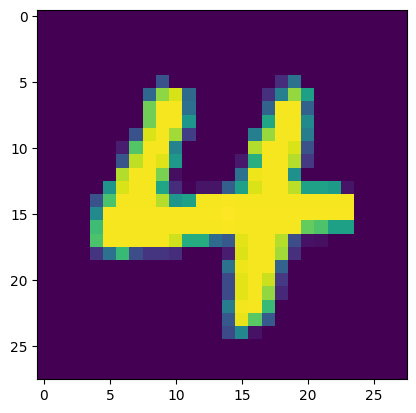

In [20]:
plt.imshow(df.iloc[df.sample().index[0],1:].values.reshape(28,28))

## Lets implement a ML Model without performing PCA to check it's Performance

In [21]:
# Seperate Feature and Target
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [22]:
# Performing Test Train Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [26]:
X_train.shape
y_train.shape

(33600,)

In [28]:
# As our data don't have any missing values let's directly implement KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

## Let's implement PCA 

In [31]:
# 1. Transform the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# 2. Implement PCA through sklearn
from sklearn.decomposition import PCA
pca = PCA(n_components = 100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [35]:
X_train_trf.shape

(33600, 100)

In [36]:
knn.fit(X_train_trf,y_train)
y_pred = knn.predict(X_test_trf)
accuracy_score(y_pred,y_test)

0.9544047619047619

In [39]:
pca.explained_variance_
# Eigen Values as we have choosen 100 components

array([40.67111198, 29.17023401, 26.74459621, 20.85344792, 18.14891878,
       15.8529825 , 13.87108101, 12.48058967, 11.02794236, 10.09582533,
        9.63317821,  8.62785945,  8.06303131,  7.89511749,  7.44167929,
        7.17032873,  6.73266373,  6.62744023,  6.41499161,  6.25808269,
        5.90495742,  5.76521585,  5.52084601,  5.32003847,  5.18309925,
        4.93439597,  4.90652171,  4.71800493,  4.49824444,  4.43140305,
        4.32604521,  4.23491831,  4.10335015,  4.0673118 ,  4.02362178,
        3.84130473,  3.81886146,  3.71316498,  3.60918108,  3.47303214,
        3.42842989,  3.38841159,  3.29157511,  3.22927379,  3.21745142,
        3.15810372,  3.12620905,  3.10412385,  3.05892795,  3.03728188,
        2.96540461,  2.94033669,  2.86828564,  2.82617865,  2.80038441,
        2.77411221,  2.71978838,  2.69394232,  2.64724369,  2.63065837,
        2.56498699,  2.53651735,  2.48789582,  2.44610051,  2.42066567,
        2.37577156,  2.35505085,  2.33408709,  2.29804042,  2.25

In [40]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [41]:
# Let's implement PCA again to find the optimum number of PCA Components
# Approach:
# 1. Apply PCA on all the Components - 784
# 2. Calculate / call _explained_variance_ratio (to find % of variance contribution by every Eigen Value)
# 3. Calculate Cummulative sum of values from step 2

In [42]:
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

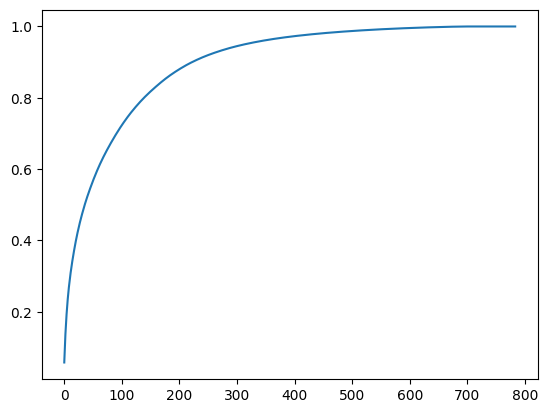

In [45]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))